##Step 04 - Azure AI Search (Hybrid BM25 + Vector)

In [ ]:
credential  = AzureKeyCredential(AZURE_SEARCH_API_KEY)
idx_client  = SearchIndexClient(endpoint=AZURE_SEARCH_ENDPOINT, credential=credential)
srch_client = SearchClient(
    endpoint=AZURE_SEARCH_ENDPOINT,
    index_name=AZURE_SEARCH_INDEX_NAME,
    credential=credential,
)
print("Azure AI Search clients ready")

Azure AI Search clients ready


In [ ]:
fields = [
    SimpleField(name="id",      type=SearchFieldDataType.String, key=True),
    SearchableField(name="content", type=SearchFieldDataType.String,
                    analyzer_name="en.microsoft"),
    SimpleField(name="title",   type=SearchFieldDataType.String, filterable=True),
    SimpleField(name="url",     type=SearchFieldDataType.String),
    SearchField(
        name="embedding",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=EMBEDDING_DIM,
        vector_search_profile_name="hnsw-profile",
    ),
]

vector_search = VectorSearch(
    algorithms=[HnswAlgorithmConfiguration(name="hnsw-algo")],
    profiles=[VectorSearchProfile(
        name="hnsw-profile",
        algorithm_configuration_name="hnsw-algo",
    )],
)

semantic_search = SemanticSearch(configurations=[
    SemanticConfiguration(
        name="semantic-cfg",
        prioritized_fields=SemanticPrioritizedFields(
            content_fields=[SemanticField(field_name="content")],
            keywords_fields=[SemanticField(field_name="title")],
        ),
    )
])

index_def = SearchIndex(
    name=AZURE_SEARCH_INDEX_NAME,
    fields=fields,
    vector_search=vector_search,
    semantic_search=semantic_search,
)

result = idx_client.create_or_update_index(index_def)
print(f"Index '{result.name}' ready (hybrid: BM25 keyword + HNSW vector)")
print(f"Fields: {[f.name for f in result.fields]}")


Index 'rag-showdown' ready (hybrid: BM25 keyword + HNSW vector)
Fields: ['id', 'content', 'title', 'url', 'embedding']


In [ ]:
BATCH = 100
print(f"Uploading {len(all_docs)} documents to Azure AI Search...")
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc="Azure upload"):
    batch_end = min(i + BATCH, len(all_docs))
    srch_client.upload_documents(documents=[
        {
            "id":        f"doc-{i + j}",
            "content":   texts[i + j],
            "title":     metas[i + j].get("title", ""),
            "url":       metas[i + j].get("url", ""),
            "embedding": all_vectors[i + j],
        }
        for j in range(batch_end - i)
    ])

print(f"Uploaded {len(all_docs)} documents in {time.perf_counter()-t0:.1f}s")

Uploading 40 documents to Azure AI Search...


Azure upload:   0%|          | 0/1 [00:00<?, ?it/s]

Uploaded 40 documents in 1.1s


In [ ]:
def azure_hybrid_search(query: str, top_k: int = TOP_K) -> list:
    """BM25 keyword + HNSW vector search, fused with Reciprocal Rank Fusion (RRF)."""
    query_vec = embedder.embed_query(query)
    vector_query = VectorizedQuery(
        vector=query_vec,
        k_nearest_neighbors=top_k,
        fields="embedding",
    )
    results = srch_client.search(
        search_text=query,              # BM25 keyword search
        vector_queries=[vector_query],  # Vector ANN search
        select=["id", "content", "title", "url"],
        top=top_k,
    )
    return list(results)

# Demo
sample_q = "How does hybrid search combine keyword and vector retrieval?"
print(f"Query: '{sample_q}'")
for i, r in enumerate(azure_hybrid_search(sample_q)):
    score = r.get("@search.score", 0)
    print(f"  [{i+1}] score={score:.4f}  [{r['title']}]  {r['content'][:100]}...")


Query: 'How does hybrid search combine keyword and vector retrieval?'
  [1] score=0.0331  [Retrieval-Augmented Generation]  . (2) Embed the user query and retrieve top-k similar chunks. (3) Inject chunks into the prompt. (4)...
  [2] score=0.0320  [Azure AI Search]  Azure AI Search (formerly Azure Cognitive Search) is a fully managed cloud search service from Micro...
  [3] score=0.0318  [BM25 Information Retrieval]  . It excels at exact keyword matching and handling rare terms. Weakness: vocabulary mismatch, no sem...
  [4] score=0.0318  [Vector Database]  A vector database stores data as high-dimensional vectors representing text, images, audio, or video...
  [5] score=0.0299  [Azure AI Search]  . Features: semantic ranker, built-in OCR, entity extraction, multi-language support, role-based acc...


In [ ]:
azure_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc="Azure AI Search benchmark"):
    t0 = time.perf_counter()
    azure_hybrid_search(q)
    azure_latencies.append((time.perf_counter() - t0) * 1000)

azure_p50 = float(np.percentile(azure_latencies, 50))
azure_p95 = float(np.percentile(azure_latencies, 95))
print(f"Azure AI Search  p50={azure_p50:.1f}ms  p95={azure_p95:.1f}ms")

Azure AI Search benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

Azure AI Search  p50=148.2ms  p95=221.5ms


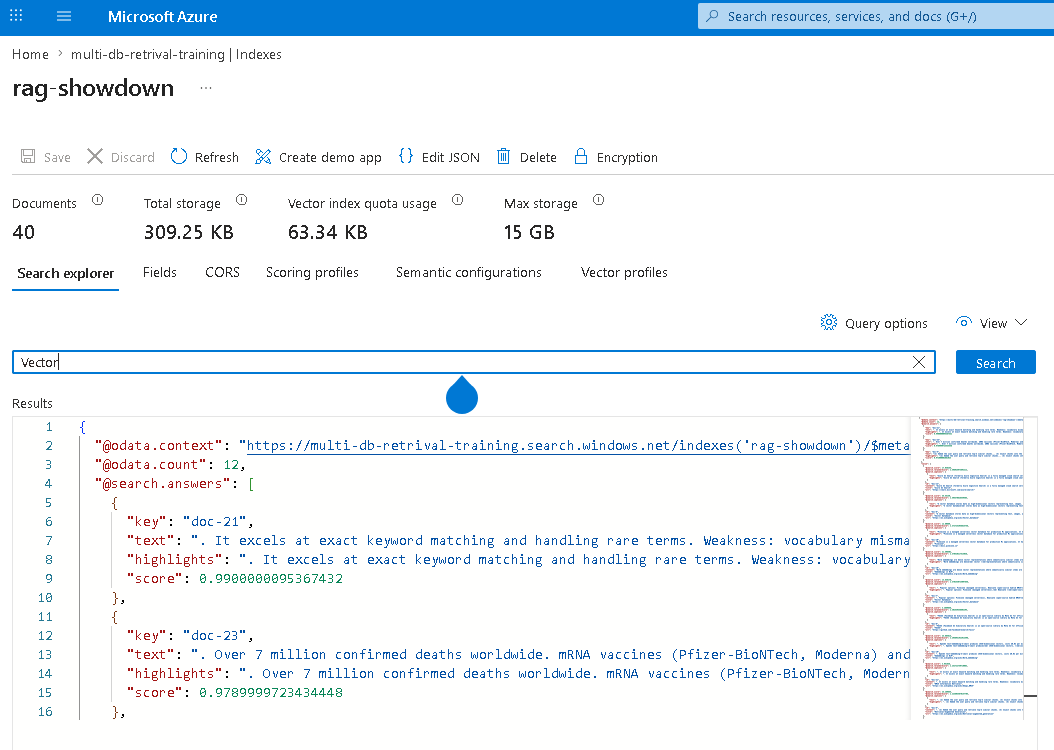